# Machine Learning for Lung Cancer Prediction: An End-to-End Classification Exercise


### Objective
Develop and evaluate a supervised classification model that predicts lung cancer from patient symptoms and determine the critical predictive features from the provided dataset



<!-- generated-team-badges: run `python scripts/update_notebook_badges.py` to refresh -->
<div align="center"><img alt="Hours" src="https://img.shields.io/badge/Hours-8h%2014m-4A4A4A?style=flat-square&logo=git&logoColor=white&labelColor=1F6FEB" /> <a href="https://github.com/jamesbarlow1812"><img alt="James Barlow" src="https://img.shields.io/badge/%20-James%20Barlow-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=7C3AED" /></a> <a href="https://github.com/JoeShade"><img alt="Joe Shade" src="https://img.shields.io/badge/%20-Joe%20Shade-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=D97706" /></a> <a href="https://github.com/Nomo2001"><img alt="Lena Kraemer" src="https://img.shields.io/badge/%20-Lena%20Kraemer-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=059669" /></a> <a href="https://github.com/SimonAndreou"><img alt="Simon Andreou" src="https://img.shields.io/badge/%20-Simon%20Andreou-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=DC2626" /></a></div>




<table style="margin-left: auto; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: center;">Team member</th>
      <th style="text-align: center;">Main responsibility</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;">James Barlow</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;">Joe Shade</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;">Lena Kraemer</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;">Simon Andreou</td>
      <td style="text-align: center;"></td>
    </tr>
  </tbody>
</table>

<p style="text-align: center;"><em>Figure 1, Student Contribution Matrix</em></p>

## 1. Problem Definition and Plan


### 1.1 ML task definition



### 1.2 Why this problem matters




In [46]:
# import Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Import the Scikit-Learn Framework NB: ≥0.20 is required
import sklearn

# 2. Data Preparation


## 2.1 Dataset overview
Describe the dataset size, number of columns, target column, and basic feature types.



In [47]:
dataset = pd.read_csv("datasets/givenData.csv", thousands=",")
dataset.columns = dataset.columns.str.strip()

dataset.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


### 2.1.1 Column definitions
Explain what each variable appears to represent.



### 2.1.2 Initial observations
Any obvious issues from the first inspection?



## 2.2 Data quality checks
What checks are we going to use before modelling?
Should list explicitly.



### 2.2.1 Missing data
State whether missing values were found.

> **Note:** No missing data identified so far.



In [48]:
# No null rows, all data is complete, nothing needs imputing
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

### 2.2.2 De-duplication

Rows 285-309 were flagged as duplicated entries and removed. 



In [49]:
print(f"Number of duplicate rows: {dataset.duplicated().sum()}")

Number of duplicate rows: 33


In [50]:
# Lots of the duplicated rows are at the end of the dataset
# safe to assume these are dupes and not just similar data points
dataset.duplicated().tail(30)


279    False
280    False
281    False
282    False
283    False
284     True
285     True
286     True
287     True
288     True
289     True
290     True
291     True
292     True
293     True
294     True
295     True
296     True
297     True
298     True
299     True
300     True
301     True
302     True
303     True
304     True
305     True
306     True
307     True
308     True
dtype: bool

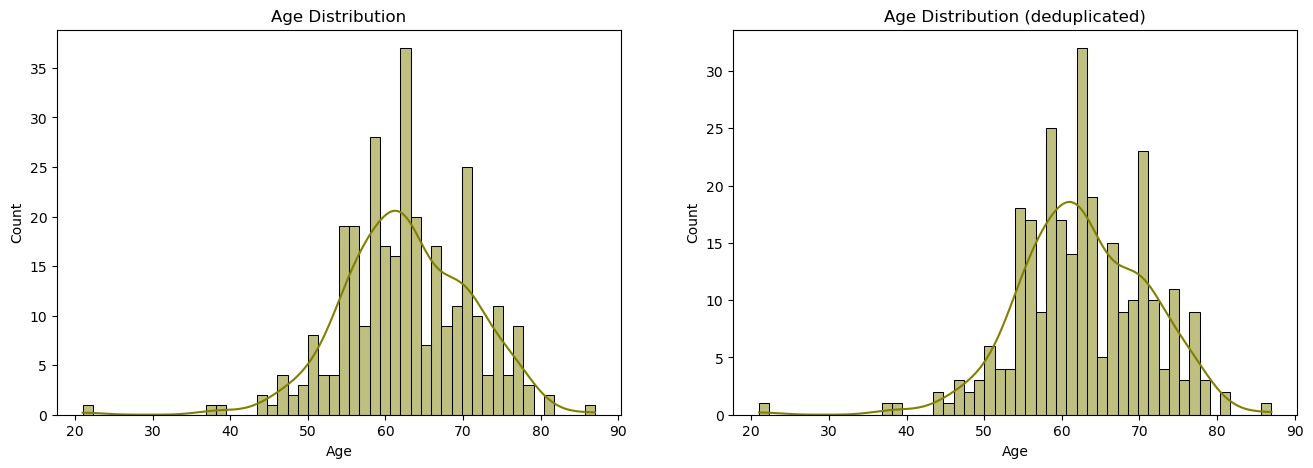

In [51]:
dataset_dedup = dataset.drop(index=dataset.index[284:]).copy()

# See if removing dupes has any impact on our only numerical feature
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=dataset, x='AGE', bins=50, kde=True, color='olive')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.subplot(1,2,2)
sns.histplot(data=dataset_dedup, x='AGE', bins=50, kde=True, color='olive')
plt.title("Age Distribution (deduplicated)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### 2.2.3 Data consistency




In [52]:
dataset_clean = dataset_dedup.copy()

dataset_clean.columns = dataset_clean.columns.str.strip()
dataset_clean.rename(columns={'CHRONIC DISEASE': 'CHRONIC_DISEASE', 'ALCOHOL CONSUMING': 'ALCOHOL_CONSUMING', 'SHORTNESS OF BREATH': 'SHORTNESS_OF_BREATH', 'SWALLOWING DIFFICULTY': 'SWALLOWING_DIFFICULTY', 'CHEST PAIN': 'CHEST_PAIN'}, inplace=True)

# 0 = no, 1 = yes
binary_yes_no_cols = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ANXIETY',
    'PEER_PRESSURE',
    'CHRONIC_DISEASE',
    'FATIGUE',
    'ALLERGY',
    'WHEEZING',
    'ALCOHOL_CONSUMING',
    'COUGHING',
    'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY',
    'CHEST_PAIN'
]
dataset_clean[binary_yes_no_cols] = dataset_clean[binary_yes_no_cols] - 1

# 0 = male, 1 = female
dataset_clean['GENDER'] = dataset_clean['GENDER'].map({'M': 0, 'F': 1})

# 0 = no, 1 = yes
dataset_clean['LUNG_CANCER'] = dataset_clean['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

dataset_clean.head(10)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0
5,1,75,0,1,0,0,1,1,1,1,0,1,1,0,0,1
6,0,52,1,0,0,0,0,1,0,1,1,1,1,0,1,1
7,1,51,1,1,1,1,0,1,1,0,0,0,1,1,0,1
8,1,68,1,0,1,0,0,1,0,0,0,0,0,0,0,0
9,0,53,1,1,1,1,1,0,1,0,1,0,0,1,1,1


## 2.3 Outlier review
Which variables were checked for outliers and why?



### 2.3.1 Age outliers
Any unusual ages or rare combinations?

> **Note:** Potential outlier 21 year old female



### 2.3.2 Decision on outliers
keep or remove? Will need to justify this, test both ways?




## 2.4 Feature engineering
Describe any new variables created and why they may improve the model.



### 2.4.1 Derived label: heavy smoker

> **Note:** Possible derived feature using **SMOKING** and **YELLOW_FINGERS**.



### 2.4.2 Age bins
Explain the logic behind age groups and why binning may help interpretation or modelling.



### 2.4.3 Any additional engineered features
Any other features?

> **Note:** Only keep engineered features that we can justify



In [53]:
# Use this block to create engineered features



In [54]:
# Recheck correlations including new features


## 2.5 Encoding and preprocessing decisions
Describe how categorical/binary variables were prepared for modelling.



In [55]:
# Use this block to create a cleaned/imputed copy of the dataset, following the decisions above


### 2.5.1 Target encoding
how we changed the LUNG_CANCER field into something the model can use.


> **E.g:** Target variable originally stored as categorical text values, converted into binary (0/1) 




### 2.5.2 Feature encoding
Same as above, changing 2 / 1 into booleans 


### 2.5.3 Scaling strategy
State whether scaling was needed and for which models.



### 2.5.4 Leakage prevention
Preprocessing decisions fitted only on training data and not on the full dataset before evaluation.
Don't train on whole dataset, reserve some for testing ect.



## 2.6 Data preparation summary
Short summary of the final cleaned dataset and the decisions made.

---



# 3. Data Analysis and Visualisation


## 3.1 Exploratory analysis goals
State what we want to learn

> **Note:** Link the analysis to model selection. 



## 3.2 Visualisation strategy
What kinds of visuals are we using and why.




State that we will prioritise visuals that reveal structure, class separation, and subgroup differences rather than just bar graphs 
> **Note:**  Maybe use correlation heatmaps, masked heatmaps, violin plots, boxplots, pairplots coloured by target. 


### 3.2.2 Statistical support for visual findings
Significance checks or statistical tests used to support visual patterns.





## 3.3 Target distribution
Show the class balance for the target variable.



### 3.3.1 Class imbalance check
Will the imbalance may modelling or metric choice.

> **Note:**  yeah, lol

## 3.4 Univariate analysis
Look at each feature on its own.



### 3.4.1 Age distribution




### 3.4.2 Symptom and lifestyle variables
Review the frequency of smoking, coughing, chest pain, wheezing, ect.



## 3.5 Bivariate analysis against the target
How each feature relates to the outcome.



### 3.5.1 Categorical/binary features vs lung cancer
Compare symptom variables and lifestyle indicators against the target.



### 3.5.2 Age vs lung cancer




### 3.5.3 Gender subgroup analysis
Check whether patterns differ by gender?





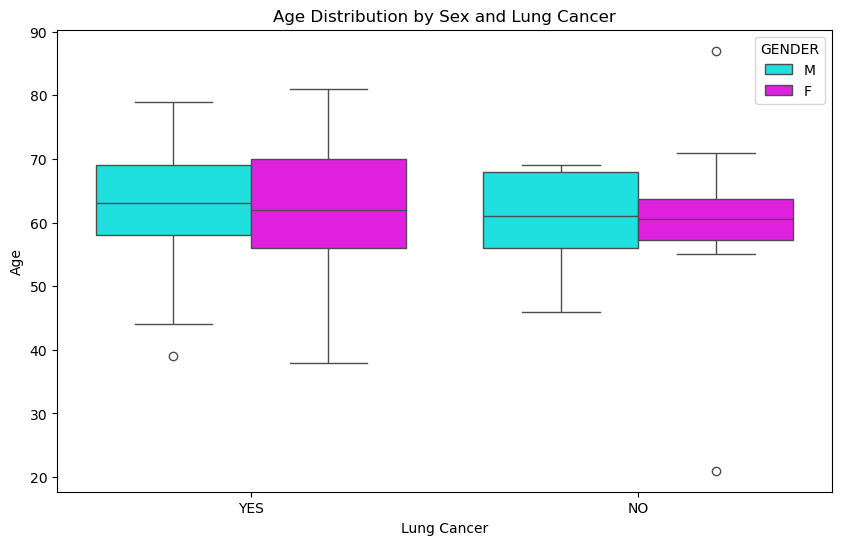

In [56]:
# Check dataset shape, column names, data types, and summary info
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x='LUNG_CANCER', y='AGE', hue='GENDER', palette={'M': 'cyan', 'F': 'magenta'})
plt.title("Age Distribution by Sex and Lung Cancer")
plt.xlabel("Lung Cancer")
plt.ylabel("Age")
plt.show()

## 3.6 Correlation and multicollinearity review
Any correlation patterns or highly related variables?



### 3.6.1 Feature relationships
Any variables that move together?



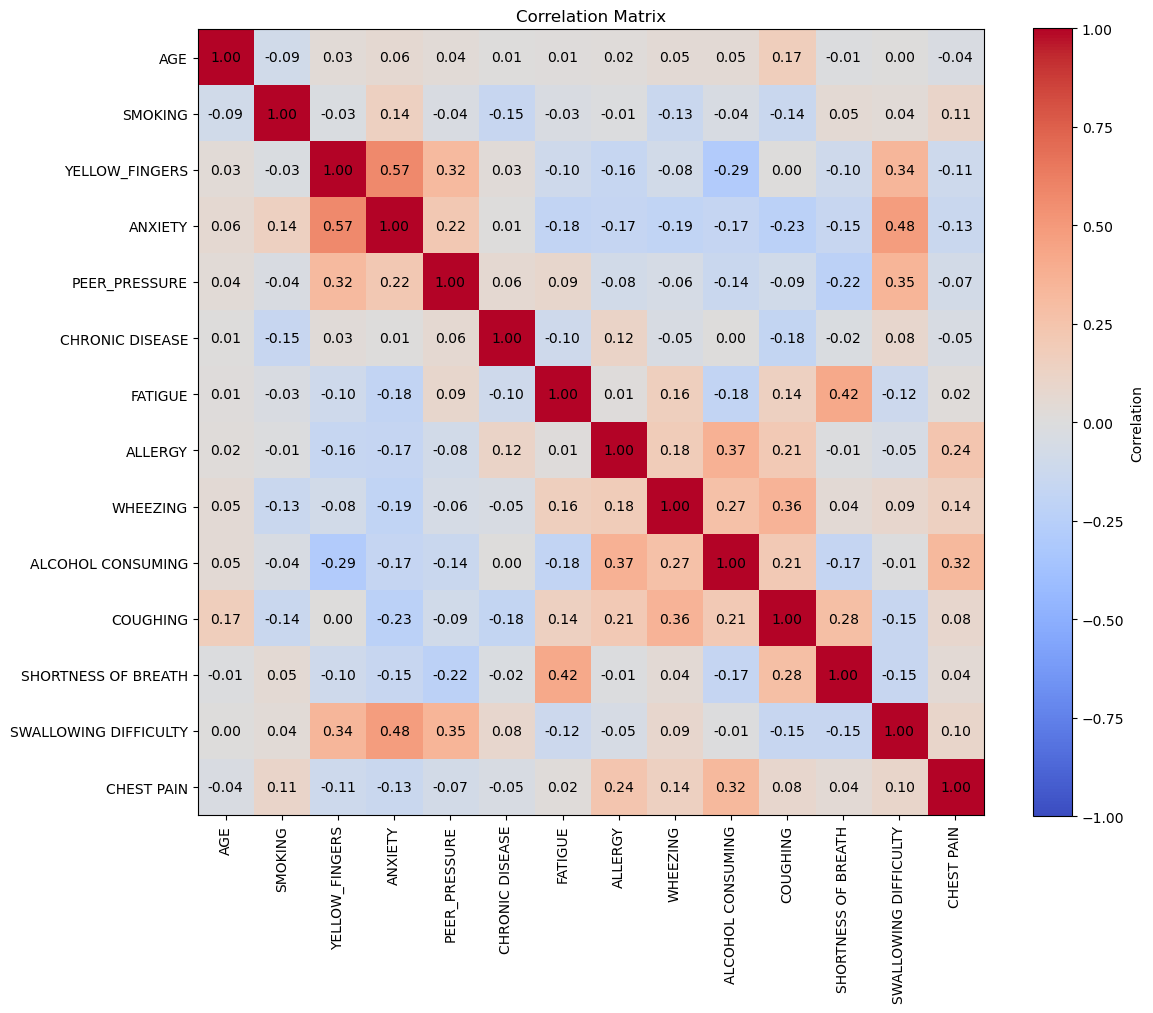

In [57]:
corr_matrix = dataset_dedup.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix')

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


### 3.6.2 Implications for modelling




## 3.7 Interpretation of key patterns
why the strongest patterns matter in the context of the case, not just statistically.




## 3.8 Visual insights that inform the ML strategy
use this to tie early data analysis into strategy





## 3.9 Data analysis summary
Concise s=ummary of the strongest findings from the EDA.



# 4. Model Selection and Training


## 4.1 Modelling approach
State overall strategy for training and comparing models.



### 4.1.1 Cross-validation strategy
how the model will be evaluated, train/test split plus Stratified K-Fold cross-validation?

> **Note:** not really sure what a stratified k-fold is, just nabbed from lecture slides



### 4.1.2 Metric priority
which metrics matter most and why.

> **Note:** recall and false negatives probably matter more than raw accuracy.



## 4.2 Baseline model
Describe the simplest model used as a benchmark.

> **Note:** will help justify later choices



## 4.3 Candidate models
create sub-section for each



## 4.4 Training decisions
Explain the main training choices.



### 4.4.1 Feature set used
original features only or included engineered features.



### 4.4.2 Hyperparameter tuning
Summarise any tuning process.



### 4.4.3 Class imbalance handling
weighting, resampling, or threshold adjustment? hybrid method?



### 4.4.4 Data pipelines
State that preprocessing and modelling steps are combined within a pipeline where appropriate.

> **Note:** buzz word soup for mel.



## 4.5 Model iteration log
basically a revision table, what changed from one experiment to the next.



### 4.5.1 First-pass model results
starting point.



### 4.5.2 What was adjusted
Record tuning, feature changes, threshold changes, or preprocessing updates.



### 4.5.3 Why the adjustment was made
Justify each change based on evidence



## 4.6 Model comparison plan
how models will be compared fairly?

> **Note:** Link this to the chosen metrics rather than just accuracy.



## 4.7 Final model choice
Which model was selected and why.

---



# 5. Results and Analysis


## 5.1 Performance metrics



### 5.1.1 Core classification metrics
Accuracy, precision, recall, F1-score, any other metrics?



### 5.1.2 Confusion matrix
could use this to explain the types of errors being made.



### 5.1.3 Threshold trade-offs
Would changing the classification threshold improve the balance between false positives and false negatives.

> **Note:**  missing a true positive may be more serious than raising a false alarm.



## 5.2 Model comparison results
Compare the candidate models




## 5.3 Feature importance and model explainability
Which features appear most important



### 5.3.1 Importance from the final model
Summarise main predictive features.



### 5.3.2 Link back to the case question
Discuss which features are most strongly associated with lung cancer in your analysis.

> **Note:** probs needs a new title



## 5.4 Error analysis
where does the model perform poorly.



### 5.4.1 False positives
Explain possible reasons.



### 5.4.2 False negatives
Explain possible reasons and why they may matter more (healthcare setting)



### 5.4.3 Subgroup error patterns
Check whether error rates differ across groups?




## 5.5 Critical discussion
Evaluate the model beyond the metric scores.
 > **Note:** how can we do this?


### 5.5.1 Strengths




### 5.5.2 Limitations
model, process and dataset


### 5.5.3 Fairness and bias considerations
Is performance consistent across subgroups and are any groups  disadvantaged by the model.

> **e.g:** the model produces more false negatives for women than men.



### 5.5.4 Improvement ideas
realist next steps



## 5.6 Results summary




# 6. Final Conclusion


## 6.1 Direct answer to the brief




## 6.2 Reflection


---



<p align="center"><img src="assets/LboroLogoSmall.png" alt="Loughborough University logo"></p>
